# Sales Prediction (Simple Linear Regression)

### Problem Statement

- A retail company has observed fluctuations in their product sales and wants to understand how their marketing expenditures influence these changes.
- The company seeks to build a simple linear regression model to predict sales based on marketing expenditure for a single platform.
- This model will help them make data-driven decisions to optimize their advertising budget and maximize returns on investment.

Build a model which predicts sales (thosands of units) based on the money spent (in thousands of dollers) on different platforms for marketing.

## Import Libraries

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Load Data

In [35]:
advertising = pd.read_csv("./Advertising.csv",index_col=0)
advertising.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## Data Inspection

In [36]:
advertising.shape

(200, 4)

In [37]:
advertising.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [38]:
advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## Data Cleaning

In [39]:
advertising.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## Outlier Analysis

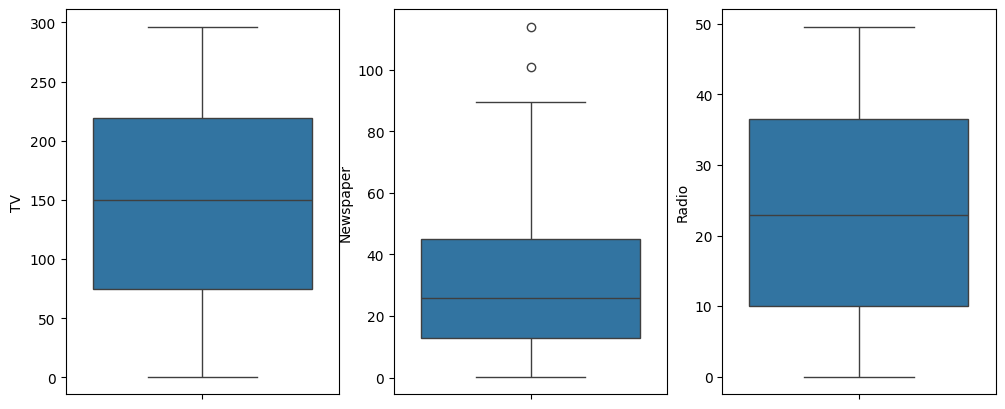

In [40]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt1 = sns.boxplot(advertising['TV'])

plt.subplot(1,3,2)
plt2 = sns.boxplot(advertising['Newspaper'])

plt.subplot(1,3,3)
plt3 = sns.boxplot(advertising['Radio'])

## Exploratory Data Analysis

### Univariate Analysis

#### Sales (Target Variable)

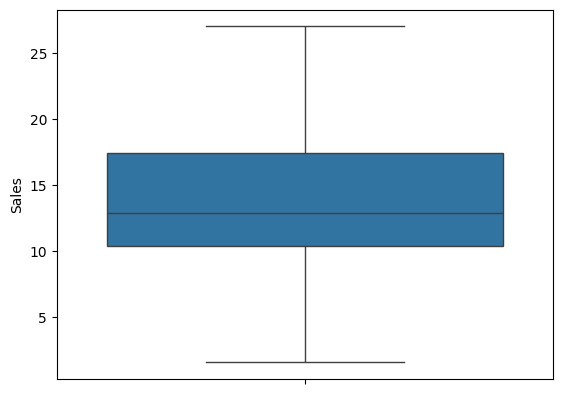

In [41]:
sns.boxplot(advertising['Sales'])
plt.show()

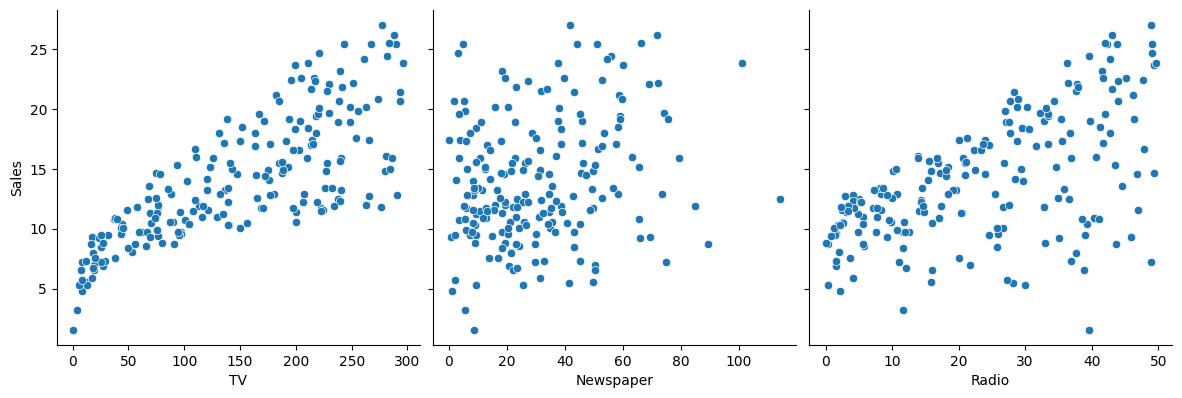

In [42]:
# Let's see how Sales are related with other variables using scatter plot.
sns.pairplot(advertising, x_vars=['TV', 'Newspaper', 'Radio'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.show()

-  we can observe that TV w.r.t Sales can be a linear regression.
-  for newspaper we cant draw a single straight line as all the data points are scattered.
-  for radio we can draw but compared to this tv is best suitable.

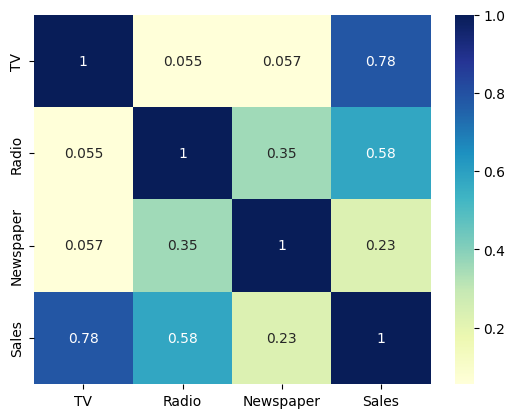

In [43]:
# Let's see the correlation between different variables.
sns.heatmap(advertising.corr(), cmap="YlGnBu", annot = True)
plt.show()

## Model Building

### Performing Simple Linear Regression

In [44]:
X = advertising['TV'] # independent variable
y = advertising['Sales']

## Train-Test Split


In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [46]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160,)
(40,)
(160,)
(40,)


In [47]:
# Let's now take a look at the train dataset
X_train.head()

80     116.0
198    177.0
39      43.1
25      62.3
123    224.0
Name: TV, dtype: float64

In [48]:
y_train.head()

80     11.0
198    12.8
39     10.1
25      9.7
123    11.6
Name: Sales, dtype: float64

#### Building a Linear Model

Import the `statsmodel.api` library to perform the linear regression.

In [49]:
!pip install statsmodels

In [50]:
import statsmodels.api as sm

- By default, the `statsmodels` library fits a line on the dataset which passes through the origin.

- But in order to have an intercept, you need to manually use the `add_constant` attribute of `statsmodels`.

- And once you've added the constant to your `X_train` dataset, you can go ahead and fit a regression line using the `OLS` (Ordinary Least Squares) attribute of `statsmodels` as shown below

In [51]:
# Add a constant to get an intercept
X_train_sm = sm.add_constant(X_train)

# Fit the resgression line using 'OLS'
lr = sm.OLS(y_train, X_train_sm).fit()

In [52]:
X_train_sm.head()

,const,TV
80,1.0,116.0
198,1.0,177.0
39,1.0,43.1
25,1.0,62.3
123,1.0,224.0


In [53]:
# Print the parameters, i.e. the intercept and the slope of the regression line fitted
lr.params

const    7.119638
TV       0.046530
dtype: float64

In [54]:
# Performing a summary operation lists out all the different parameters of the regression line fitted
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     228.5
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.68e-32
Time:                        08:03:45   Log-Likelihood:                -415.93
No. Observations:                 160   AIC:                             835.9
Df Residuals:                     158   BIC:                             842.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1196      0.530     13.446      0.0

## Observations :
- From the parameters that we get, our linear regression equation becomes:

- $ Sales = 7.1196 +  0.0465 \times TV $

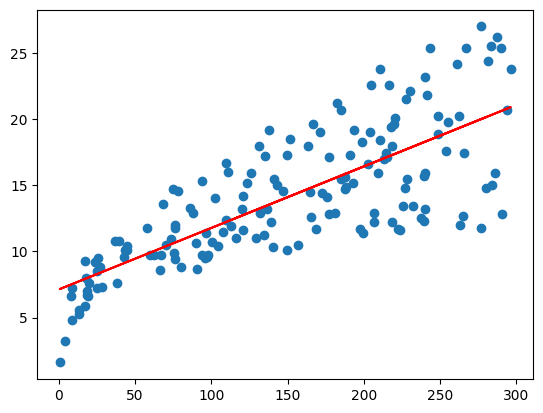

In [63]:
plt.scatter(X_train, y_train)
plt.plot(X_train, 7.1196 +  0.0465*X_train, 'r')
plt.show()

## Model Evaluation

#### Distribution of the error terms
We need to check if the error terms are also normally distributed (which is infact, one of the major assumptions of linear regression), let us plot the histogram of the error terms and see what it looks like.

In [56]:
y_train_pred = lr.predict(X_train_sm)
res = (y_train - y_train_pred)

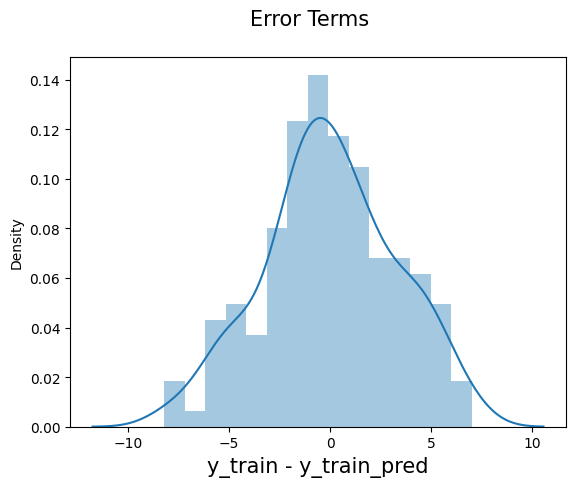

In [57]:
fig = plt.figure()
sns.distplot(res, bins = 15)
fig.suptitle('Error Terms', fontsize = 15)                  # Plot heading
plt.xlabel('y_train - y_train_pred', fontsize = 15)         # X-label
plt.show()

The residuals are following the normally distributed with a mean 0. All good!

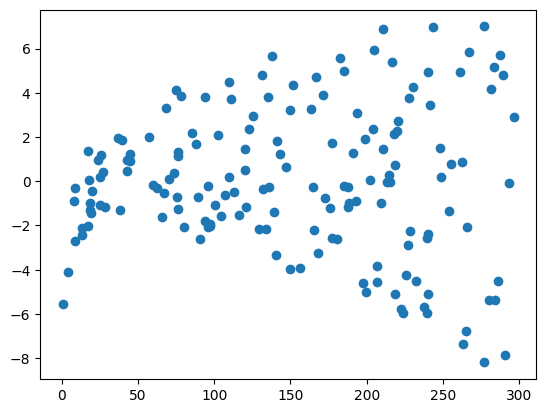

In [71]:
plt.scatter(X_train,res)
plt.show()

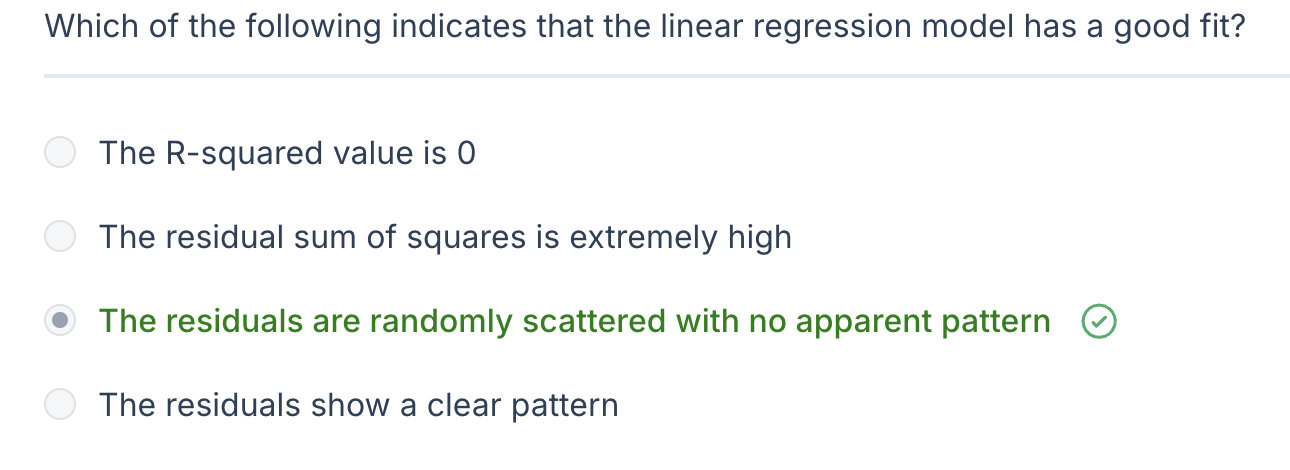

### Predictions on the Test Set

- First need to add a constant to the `X_test` data like you did for `X_train` and then you can simply go on and predict the y values corresponding to `X_test` using the `predict` attribute of the fitted regression line.

In [58]:
# Add a constant to X_test
X_test_sm = sm.add_constant(X_test)

# Predict the y values corresponding to X_test_sm
y_pred = lr.predict(X_test_sm)

In [59]:
y_pred.head()

96     14.717944
16     16.211548
31     20.748197
159     7.664036
129    17.370139
dtype: float64

In [60]:
from sklearn.metrics import mean_squared_error, r2_score

##### Looking at the MSE

In [65]:
#Returns the mean squared error; we'll take a square root
MSE = np.sqrt(mean_squared_error(y_test, y_pred))
MSE

3.194472431998898

##### Visualizing the fit on the test set

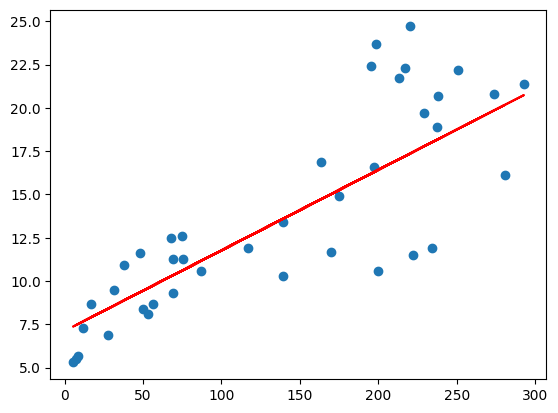

In [64]:
plt.scatter(X_test, y_test)
plt.plot(X_test, 7.1196 +  0.0465 * X_test, 'r')
plt.show()